# Preprocessing

In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
import numpy as np

# load the dataset
df = pd.read_csv('/kaggle/input/datasets/fedesoriano/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv')   

# drop 'id'
df = df.drop('id', axis=1)

print(df['stroke'].value_counts())
print(df.info())

stroke
0    4861
1     249
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB
None


## Feature Engineering
Missing value handling, outlier handling, encoding, normalization

In [2]:
# missing value handling
gender_bmi_avg = df.groupby('gender')['bmi'].transform(lambda x: x.fillna(x.mean()))
df['bmi'] = df['bmi'].fillna(gender_bmi_avg)


# drop 'other' from gender as 1 row only. doen't affect model
df = df[df['gender'].isin(['Male', 'Female'])].copy()


categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(df[col].value_counts(dropna=False))   
    print("\n" + "-"*40 + "\n")

gender
Female    2994
Male      2115
Name: count, dtype: int64

----------------------------------------

ever_married
Yes    3353
No     1756
Name: count, dtype: int64

----------------------------------------

work_type
Private          2924
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

----------------------------------------

Residence_type
Urban    2596
Rural    2513
Name: count, dtype: int64

----------------------------------------

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: count, dtype: int64

----------------------------------------



## Correlation before feature engineering

<Axes: >

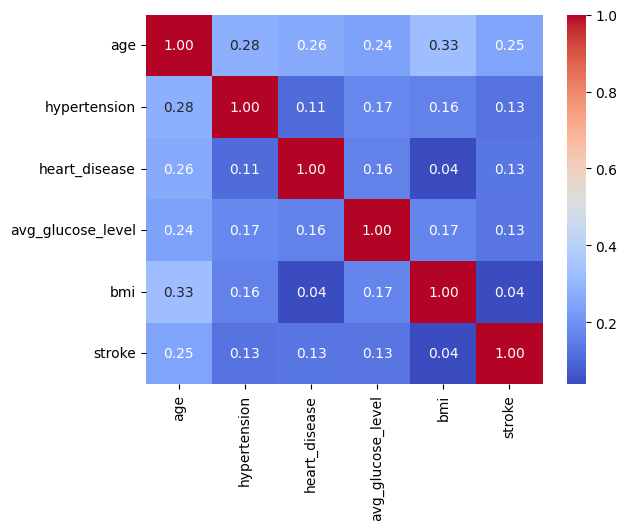

In [3]:
numeric_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
import seaborn as sns
corr_matrix=df[numeric_cols].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

In [4]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.065758,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,29.065758,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


### Categorical Encoding and Normalization

In [5]:
# apply binary category: as gender, ever_married, Residence_type belong to two category
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
df['ever_married'] = df['ever_married'].map({'No': 0, 'Yes': 1})
df['Residence_type'] = df['Residence_type'].map({'Rural': 0, 'Urban': 1})

# apply One-hot encode to 'work_type':  nominal variables 
df = pd.get_dummies(df, columns=['work_type'], drop_first=True)


# apply ordinal encode for smoke
smoking_map = {'never smoked': 0, 'formerly smoked': 1, 'smokes': 2, 'Unknown': 3}
df['smoking_status'] = df['smoking_status'].map(smoking_map)


# Normalize Numerical Features
num_cols = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

## correlation after encoding others column

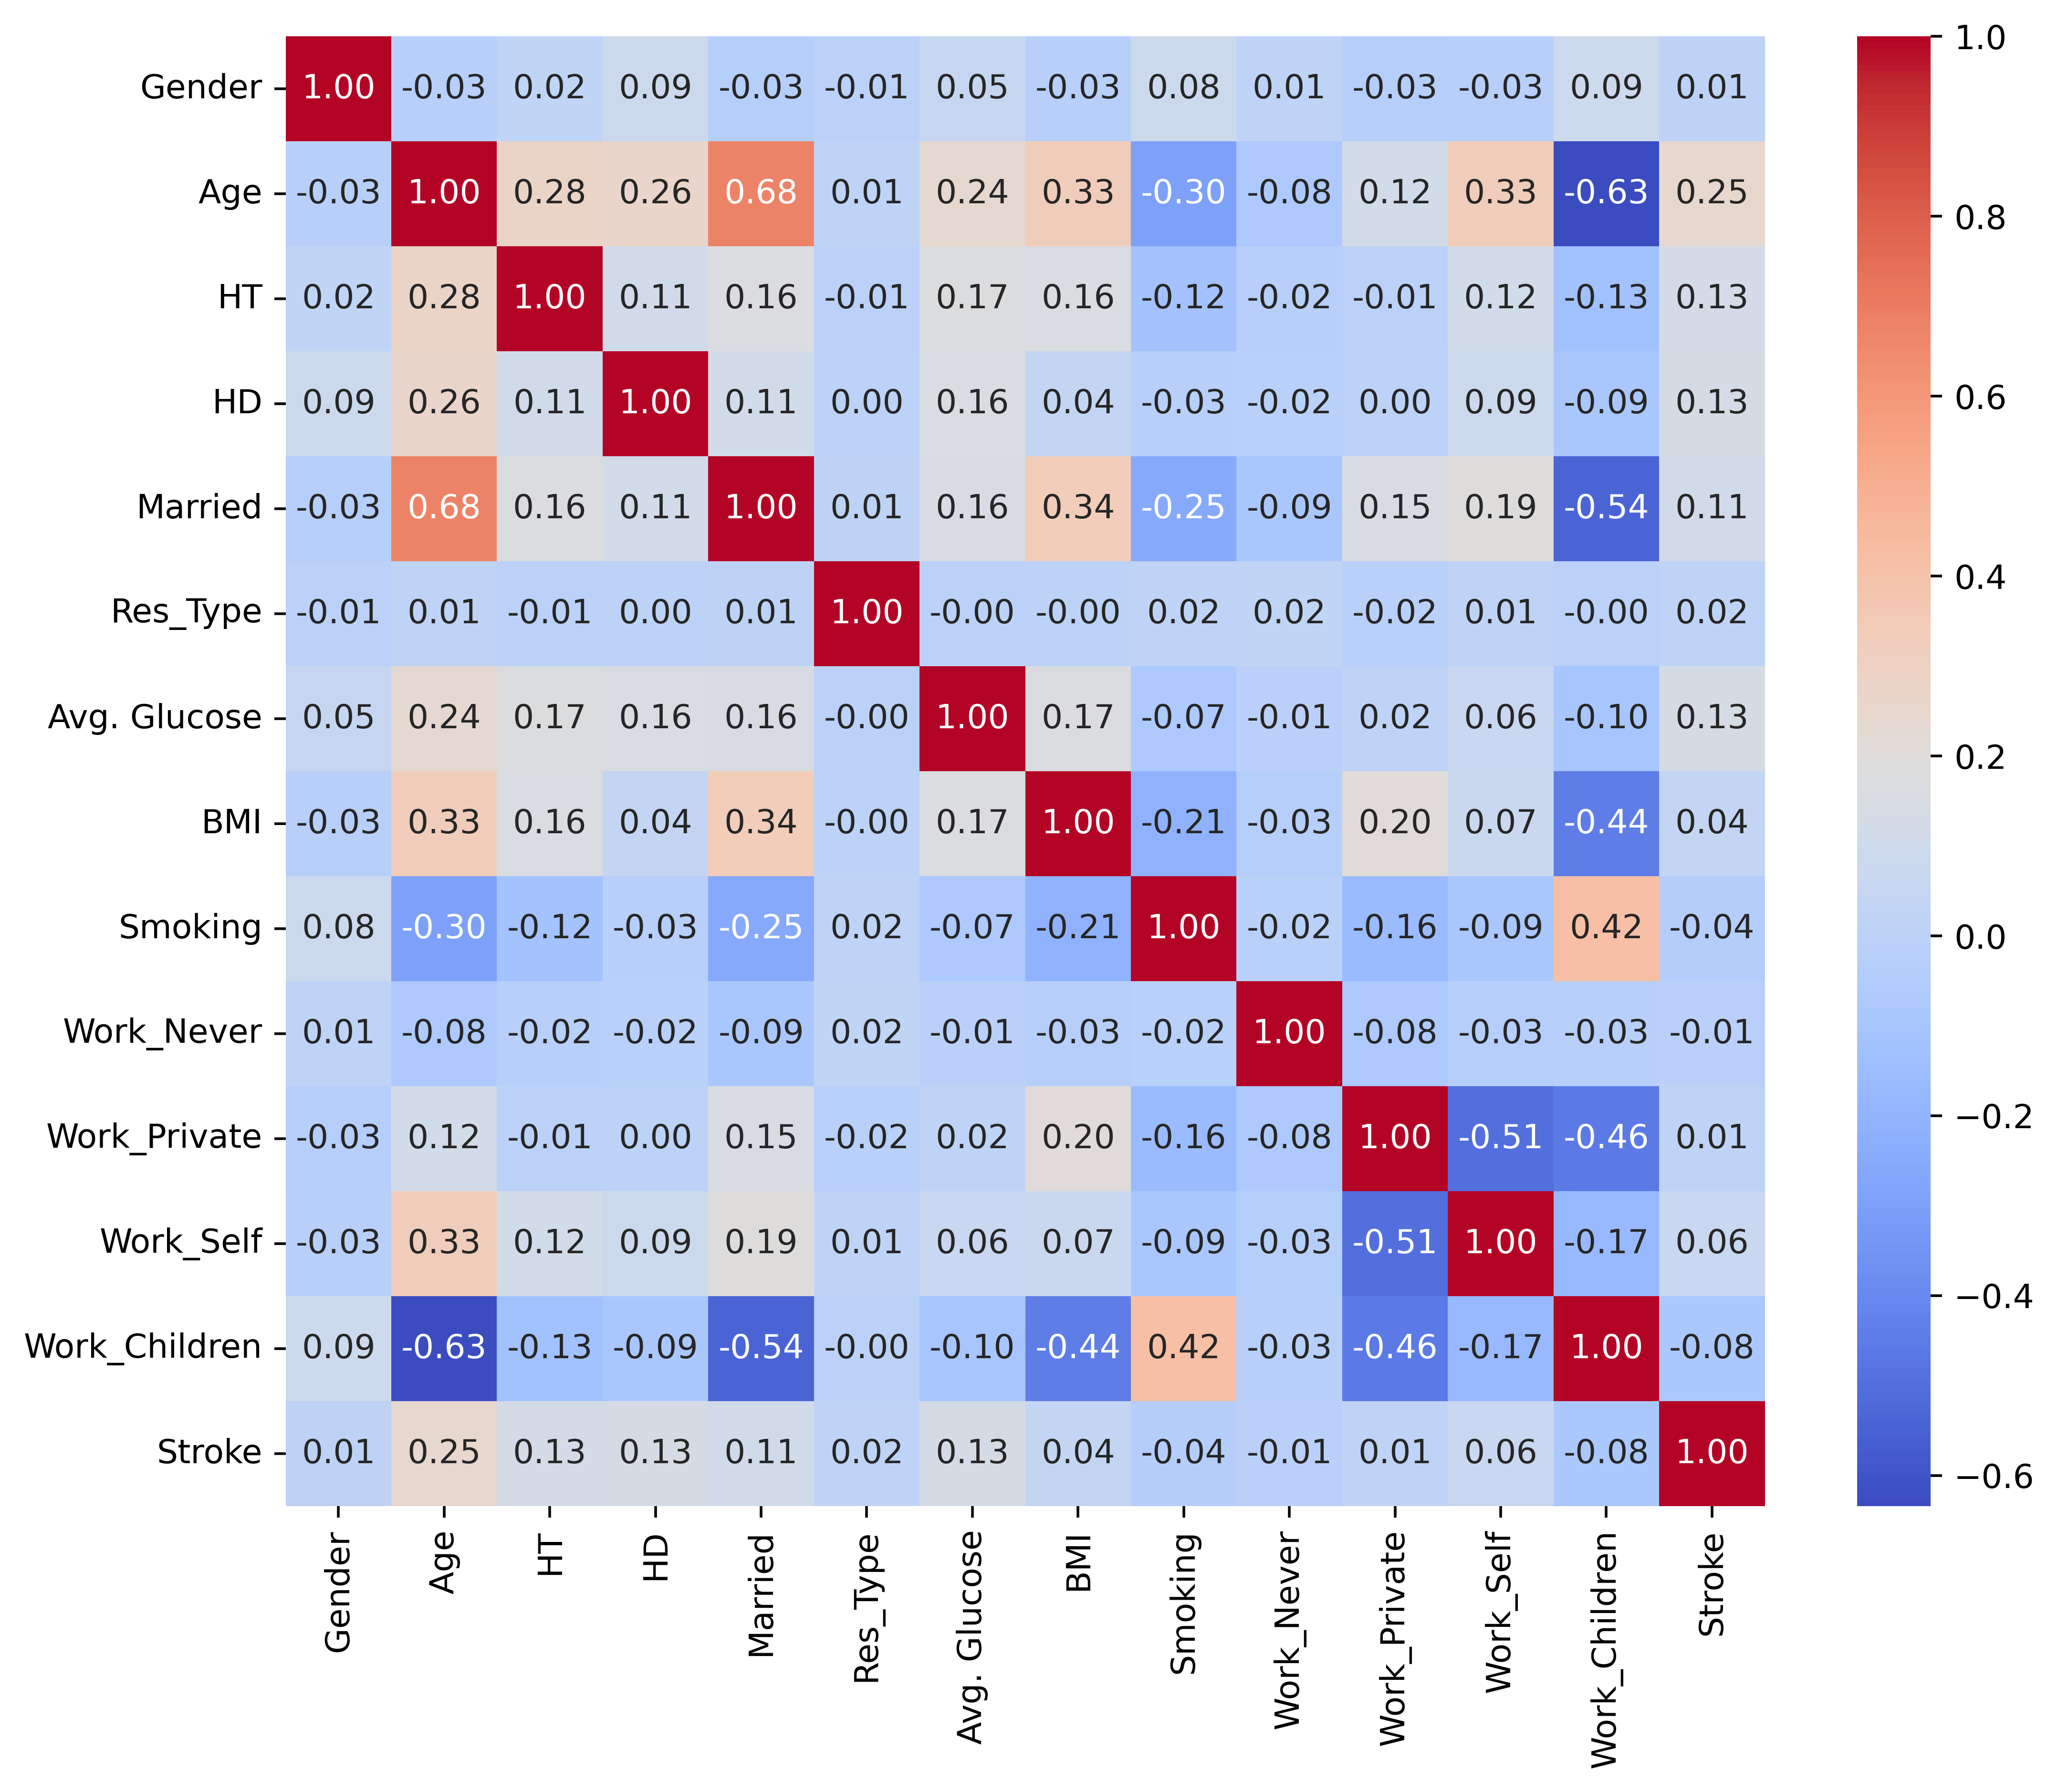

In [6]:
import matplotlib.pyplot as plt

# original column names to shorter names
rename_dict = {
    'gender': 'Gender',
    'age': 'Age',
    'hypertension': 'HT',
    'heart_disease': 'HD',
    'ever_married': 'Married',
    'Residence_type': 'Res_Type',
    'avg_glucose_level': 'Avg. Glucose',
    'bmi': 'BMI',
    'smoking_status': 'Smoking',
    'stroke': 'Stroke',
    'work_type_Never_worked': 'Work_Never',
    'work_type_Private': 'Work_Private',
    'work_type_Self-employed': 'Work_Self',
    'work_type_children': 'Work_Children'
}

df_renamed = df.rename(columns=rename_dict)

# keep 'stroke' to last
columns = ['Gender', 'Age', 'HT', 'HD', 'Married', 'Res_Type', 'Avg. Glucose', 'BMI', 'Smoking', 
           'Work_Never', 'Work_Private', 'Work_Self', 'Work_Children', 'Stroke']
df_renamed = df_renamed[columns]

# generate heatmap
plt.figure(figsize=(10, 8), dpi=500)
corr_matrix = df_renamed.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.savefig('correlation_heatmap_plot.pdf', format='pdf', dpi=300)
plt.show()


## Correlation analysis and remove features

In [7]:
# after correlation analysis, some features were removed
# as thery are very less correlated to outcome
# features to remove
features_to_remove = ['work_type_Never_worked', 'work_type_children']
# features_to_remove = ['gender', 'Residence_type', 'work_type_Never_worked', 
#                       'work_type_Private', 'work_type_children']

# Remove the features and reassign to df
df = df.drop(columns=features_to_remove)

# Verify the changes
print(df.head())


   gender       age  hypertension  heart_disease  ever_married  \
0       1  1.051242             0              1             1   
1       0  0.785889             0              0             1   
2       1  1.626174             0              1             1   
3       0  0.255182             0              0             1   
4       0  1.581949             1              0             1   

   Residence_type  avg_glucose_level       bmi  smoking_status  stroke  \
0               1           2.706450  1.001249               1       1   
1               0           2.121652  0.022470               0       1   
2               0          -0.004867  0.468615               0       1   
3               1           1.437473  0.715445               2       1   
4               0           1.501297 -0.635626               0       1   

   work_type_Private  work_type_Self-employed  
0               True                    False  
1              False                     True  
2             

## Outlier detection and handling usin IQR

In [8]:
# Handling outliers using IQR method
outlier_counts = {}  # Dictionary to track the number of outliers for each column

for col in['age', 'bmi', 'avg_glucose_level']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"Column: {col}, lower_bound: {lower_bound} and upper_bound: {upper_bound}")
    
    # Identifying outliers before clipping
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_counts[col] = outliers
    
    # Clipping outliers
    df[col] = np.clip(df[col], lower_bound, upper_bound)

# Output the count of outliers for each numerical column
print("Outliers count per column:", outlier_counts)


Column: age, lower_bound: -3.1944111114889555 and upper_bound: 3.1740685688506947
Column: bmi, lower_bound: -2.4154015105580324 and upper_bound: 2.2613820488130933
Column: avg_glucose_level, lower_bound: -1.8589738686749107 and upper_bound: 1.3962853939655286
Outliers count per column: {'age': np.int64(0), 'bmi': np.int64(126), 'avg_glucose_level': np.int64(627)}


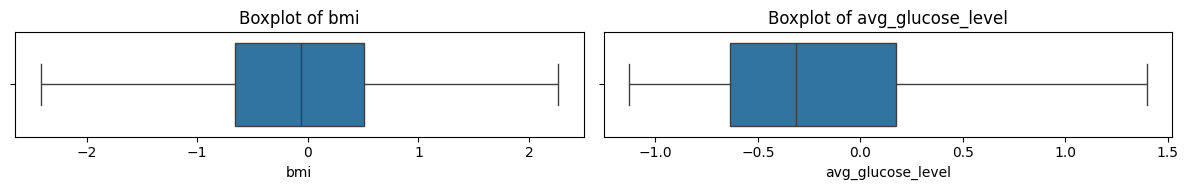

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['bmi', 'avg_glucose_level']

# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 2))

# Boxplot for each numerical column
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])  # Assign each boxplot to a subplot
    axes[i].set_title(f"Boxplot of {col}")

# Display the plot
plt.tight_layout()
plt.show()


## Dataset splitting

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('stroke', axis=1)
y = df['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(y_train.value_counts())
print(y_test.value_counts())

stroke
0    3888
1     199
Name: count, dtype: int64
stroke
0    972
1     50
Name: count, dtype: int64


## Class distribution

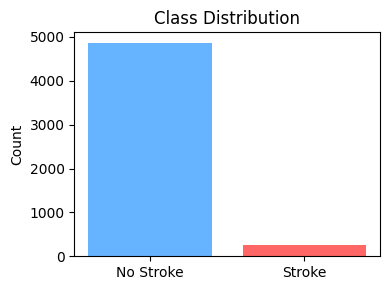

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(4, 3))
plt.bar([0, 1], df['stroke'].value_counts(), color=['#66b3ff', '#ff6666'])

# Set plot title and labels
plt.title('Class Distribution')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Stroke', 'Stroke'])

# Show the plot
plt.tight_layout()
plt.savefig('imbalance_class_distribution.pdf', format='pdf')
plt.show()


## Goemetric Mean (G-Mean) util

In [12]:
# Define G-Mean function
def gmean_score(y_true, y_pred):
    """
    Calculate Geometric Mean for binary classification
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    gmean = np.sqrt(sensitivity * specificity)
    return gmean

## Styled classification report util
We generated customized report for large font size, padding add and so one. there is no experimentation, it is just way of display classification report of any model 

In [13]:
def styled_classification_report(report_dict, font_size=24, padding_lr=10, padding_tb=3):
    import pandas as pd

    df = pd.DataFrame(report_dict).T

    # Convert to numeric (so formatting works)
    for col in ["precision", "recall", "f1-score", "support"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Create padding string
    padding_value = f"{padding_tb}px {padding_lr}px"   # top/bottom | left/right

    # Return styled report
    return (
        df.style
        .format("{:.2f}")
        .set_table_styles([
            {"selector": "th", "props": [("font-size", f"{font_size}px"), ("padding", padding_value)]},
            {"selector": "td", "props": [("font-size", f"{font_size}px"), ("padding", padding_value)]},
        ])
        .set_properties(**{"text-align": "center"})
    )


# Imbalance learning
We train 10 state-of-the art models: ML(4), DL, Ensemble(5) with Proposed stackign ensemble with imbalance data (no SMOTE or any sampling technique was used). at last we performed test set evaluation.

- **ML models:**
  Logistic Regression, Decision Tree, Support Vector Classifier, KNN.

- **DL models:**
  Deep Learning

- **Ensemble models:**
  Random Forest, XGBClassifier, AdaBoosts, LGBM and Proposed Stacking Ensemble.

## Baseline ML and two ensemble

In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# all model setup
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(
        eval_metric='logloss',
        n_estimators=1000,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    ),
}

print("\nTest Set Evaluation:")

test_results = {
    'Model': [],
    'Test Precision': [],
    'Test Recall': [],
    'Test F1': [],
    'Test AUC-ROC': [],
    'Test G-Mean': []
}

for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)

    test_results['Model'].append(model_name)
    test_results['Test Precision'].append(precision_score(y_test, y_pred, pos_label=1, zero_division=0))
    test_results['Test Recall'].append(recall_score(y_test, y_pred, pos_label=1))
    test_results['Test F1'].append(f1_score(y_test, y_pred, pos_label=1))
    test_results['Test AUC-ROC'].append(roc_auc_score(y_test, y_prob))
    test_results['Test G-Mean'].append(gmean_score(y_test, y_pred))

test_results_df = pd.DataFrame(test_results)
print(test_results_df)

classification_reports = {}
test_probabilities = {}

print("\nIndividual Model Reports:")

for model_name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)

    test_probabilities[model_name] = y_prob_test

    print(f"\n========={model_name}===========")

    print("Classification Report:")
    report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
    classification_reports[model_name] = report
    print(classification_report(y_test, y_pred, zero_division=0))

    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    gmean = gmean_score(y_test, y_pred)
    print(f"G-Mean: {gmean:.4f}")

    print("AUC ROC:")
    print(roc_auc_score(y_test, y_prob_test))


print("\n" + "="*50)
print("MODELS RANKED BY G-MEAN (Best for Imbalanced Data):")
print("="*50)

gmean_ranked = test_results_df.sort_values('Test G-Mean', ascending=False)
print(gmean_ranked[['Model', 'Test G-Mean', 'Test Recall', 'Test AUC-ROC']])


Test Set Evaluation:
                 Model  Test Precision  Test Recall   Test F1  Test AUC-ROC  \
0  Logistic Regression        0.000000         0.00  0.000000      0.840473   
1        Decision Tree        0.108108         0.16  0.129032      0.546049   
2        Random Forest        0.500000         0.04  0.074074      0.791780   
3                  SVM        0.000000         0.00  0.000000      0.704753   
4                  KNN        0.666667         0.04  0.075472      0.610751   
5              XGBoost        0.240000         0.12  0.160000      0.792942   

   Test G-Mean  
0     0.000000  
1     0.386181  
2     0.199794  
3     0.000000  
4     0.199897  
5     0.343008  

Individual Model Reports:

=========Logistic Regression===========
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1

## Baseline Deep Learning
We use Multi-layer perceptron (MLP) wiht Dense, dropuout layers. we train this model with imbalance dataset.

In [15]:
import tensorflow as tf
import math
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# compile the model with binary_crossentropy as binary classification.
model.compile(
    loss='binary_crossentropy',  
    optimizer=Adam(learning_rate=0.001),   
    metrics=['accuracy']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# fit the model on training dataset
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test), 
    epochs=100,  
    batch_size=16,   
    callbacks=[early_stopping],   
    # class_weight=class_weights,  
    verbose=1
)

# Mprediction
y_pred = (model.predict(X_test) > 0.5).astype(int)  
y_pred_proba = model.predict(X_test)   

model_name = "Deep Learning"


# all metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nG-Mean Value: ", gmean_score(y_test, y_pred))

2026-03-13 04:09:40.439610: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773374980.703829      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773374980.788974      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773374981.432316      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773374981.432392      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773374981.432395      55 computation_placer.cc:177] computation placer alr

Epoch 1/100


2026-03-13 04:10:10.956066: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9175 - loss: 0.3010 - val_accuracy: 0.9511 - val_loss: 0.1681
Epoch 2/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9491 - loss: 0.1793 - val_accuracy: 0.9511 - val_loss: 0.1644
Epoch 3/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9504 - loss: 0.1722 - val_accuracy: 0.9511 - val_loss: 0.1666
Epoch 4/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9476 - loss: 0.1741 - val_accuracy: 0.9511 - val_loss: 0.1659
Epoch 5/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9461 - loss: 0.1732 - val_accuracy: 0.9511 - val_loss: 0.1686
Epoch 6/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9513 - loss: 0.1628 - val_accuracy: 0.9511 - val_loss: 0.1670
Epoch 7/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9485 - loss: 0.1684 - val_accuracy: 0.9511 - val_loss: 0.1683
Epoch 8/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9507 - loss: 0.1549 - val_accuracy: 0.9511

## Baseline Boosting and Proposed Stacking Ensemble
We train AdaBoost, LightGBM and Proposed Stacking ensemble (class-weighted) with imbalance. 

**Note:** Voting, Bagging doesn't improve with previos models. so we are not explicitly showed them.

### Boosting

In [16]:
from sklearn.ensemble import AdaBoostClassifier
from lightgbm import LGBMClassifier

# boosting models with optimized parameters for imbalanced data
boosting_models = {
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=1000,
        learning_rate=0.5,
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=1000,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        random_state=42,
    )
}


# Evaluate each boosting ensemble
for model_name, model in boosting_models.items():
    print("="*60)
    print(f"{model_name} ENSEMBLE PERFORMANCE")
    print("="*60)
    
    # Train and predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
    print(f"G Mean for {model_name}: ", gmean_score(y_test, y_pred))
    
    print("\n" + "="*60 + "\n")

AdaBoost ENSEMBLE PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022


Confusion Matrix:
[[972   0]
 [ 50   0]]
AUC-ROC: 0.8340
G Mean for AdaBoost:  0.0


LightGBM ENSEMBLE PERFORMANCE
[LightGBM] [Info] Number of positive: 199, number of negative: 3888
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001313 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 4087, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048691 -> initscore=-2.972345
[Lig

## Proposed model

In [17]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

### Hyperparameter tune for meta-learner

In [18]:
# we use weight 1.0 for no stroke, and 19.5 for stroke class
# we examine this class_weights as best weight by up/down weight.
# you can up/down and re-run this model to see the performance up/down
class_weights = {0: 1.0, 1: 19.5} 


# define hyperparameters to tune
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],  
    'solver': ['liblinear'],  
    'max_iter': [50, 100, 200, 500, 1000],   
    'penalty': ['l2', 'l1']  # Regularization penalties (L1 for Lasso, L2 for Ridge)
}

# apply grid search cv
lr = LogisticRegression(class_weight=class_weights, random_state=42)
grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)

# Flatten y_train using .ravel()
grid_search.fit(X_train, y_train.values.ravel())

# Get best parameters from GridSearchCV
print(f"Best parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'C': 1, 'max_iter': 50, 'penalty': 'l2', 'solver': 'liblinear'}


In [19]:
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
import math

# we use weight 1.0 for no stroke, and 19.5 for stroke class
# we examine this class_weights as best weight by up/down weight.
# you can up/down and re-run this model to see the performance up/down
class_weights = {0: 1.0, 1: 19.5}  # as lass imbalance: 1:19.5 (for stroke)

# base learners
base_learners = [
    ('xgb', XGBClassifier(scale_pos_weight=19.5, eval_metric='logloss', random_state=42)),  
    ('svc', SVC(kernel='linear', class_weight=class_weights, probability=True, random_state=42)), 
    ('knn', KNeighborsClassifier(n_neighbors=3)),  
]

# meta-learner as Logistic Regression
meta_learner = LogisticRegression(max_iter=50, C=1, penalty='l2', solver='liblinear', class_weight=class_weights)

# create stacking meta-learning classifier
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_learner)

# fit stacking ensemble learning
stacking_model.fit(X_train, y_train)

# make predictions on the test data
y_pred = stacking_model.predict(X_test)
y_pred_proba = stacking_model.predict_proba(X_test)[:, 1]  

# all metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {(roc_auc_score(y_test, y_pred_proba))}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"G Mean for {model_name}: ", gmean_score(y_test, y_pred))

# Best parameters: {'C': 1, 'max_iter': 50, 'penalty': 'l2', 'solver': 'liblinear'}


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90       972
           1       0.20      0.80      0.31        50

    accuracy                           0.83      1022
   macro avg       0.59      0.82      0.61      1022
weighted avg       0.95      0.83      0.87      1022

AUC-ROC: 0.8381481481481481

Confusion Matrix:
[[807 165]
 [ 10  40]]
G Mean for LightGBM:  0.8149831475952111


# Interpretability (SHAP)

In [20]:
# !pip install --quiet --upgrade scikit-learn shap

# from IPython import display
# display.clear_output()

## Features importance

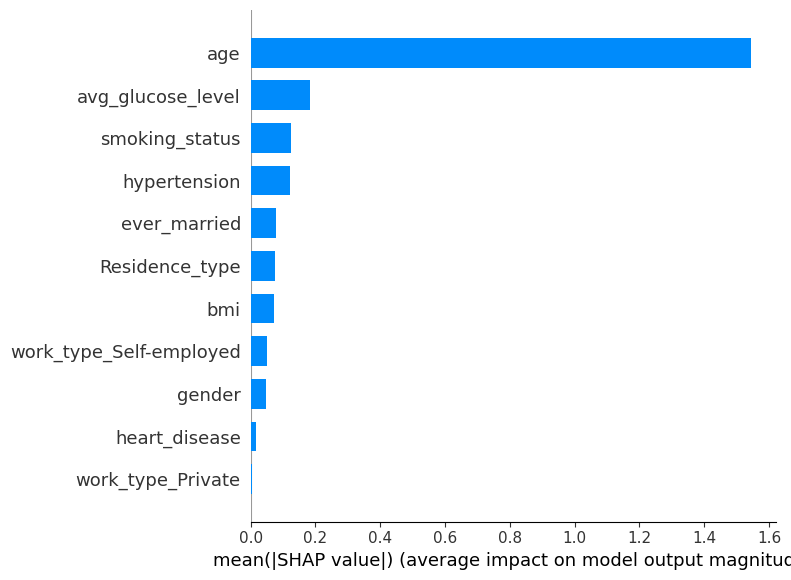

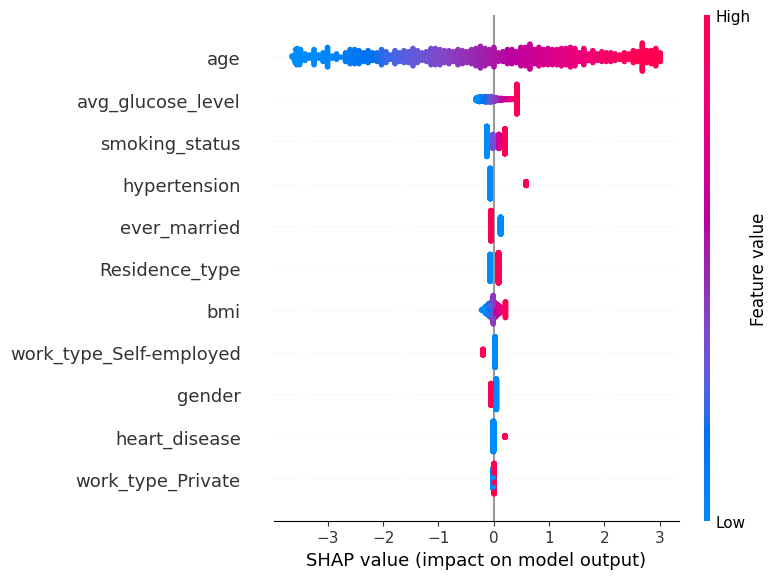

In [21]:
import pandas as pd
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

class_weights = {0: 1, 1: 19.5}


# ===========================
# 3. Train Logistic Regression
# ===========================
model = LogisticRegression(max_iter=50, C=1, penalty='l2', solver='liblinear', class_weight=class_weights)
model.fit(X_train, y_train)


# SHAP for Logistic Regression
explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer.shap_values(X_test)  # Returns ndarray, not list

# Convert SHAP values to numpy array with float64
shap_values_safe = np.array(shap_values, dtype=np.float64)

shap.summary_plot(shap_values_safe, X_test, plot_type="bar")
shap.summary_plot(shap_values_safe, X_test)

## Model contribution

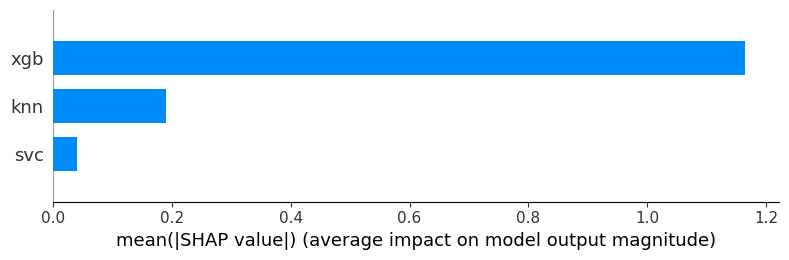

In [25]:
# =======================================
# Meta-Learner (Logistic Regression)
# =======================================
import shap
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# ---- 1️⃣ Recreate or reuse base learners ----
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# base learners (same as before)
base_learners = [
    ('xgb', XGBClassifier(scale_pos_weight=19.5, eval_metric='logloss', random_state=42, use_label_encoder=False)),
    ('svc', SVC(kernel='linear', class_weight={0: 1.0, 1: 19.5}, probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=3))
]

# ---- 2️⃣ Fit base learners ----
for name, model in base_learners:
    model.fit(X_train, y_train)

# ---- 3️⃣ Generate meta-features (probabilities of positive class) ----
meta_train = np.column_stack([model.predict_proba(X_train)[:, 1] for _, model in base_learners])
meta_test  = np.column_stack([model.predict_proba(X_test)[:, 1]  for _, model in base_learners])
meta_feature_names = [name for name, _ in base_learners]

# Convert to DataFrame for SHAP readability
meta_train_df = pd.DataFrame(meta_train, columns=meta_feature_names)
meta_test_df  = pd.DataFrame(meta_test,  columns=meta_feature_names)

# ---- 4️⃣ Train the meta-learner (Logistic Regression) ----
class_weights = {0: 1.0, 1: 19.5}
meta_learner = LogisticRegression(max_iter=50, C=1, penalty='l2', solver='liblinear', class_weight=class_weights)
meta_learner.fit(meta_train_df, y_train)

# model level
explainer_meta = shap.LinearExplainer(meta_learner, meta_train_df)
shap_values_meta = explainer_meta.shap_values(meta_test_df)

shap.summary_plot(shap_values_meta, meta_test_df, plot_type="bar")

## 10 samples of stroke and non-stroke cases SHAP tree explainer

Stroke cases: [88, 226, 242]
No-stroke cases: [3699, 3604, 2814]
True label       : 1
Predicted label  : 0
Predicted prob.  : 0.2739


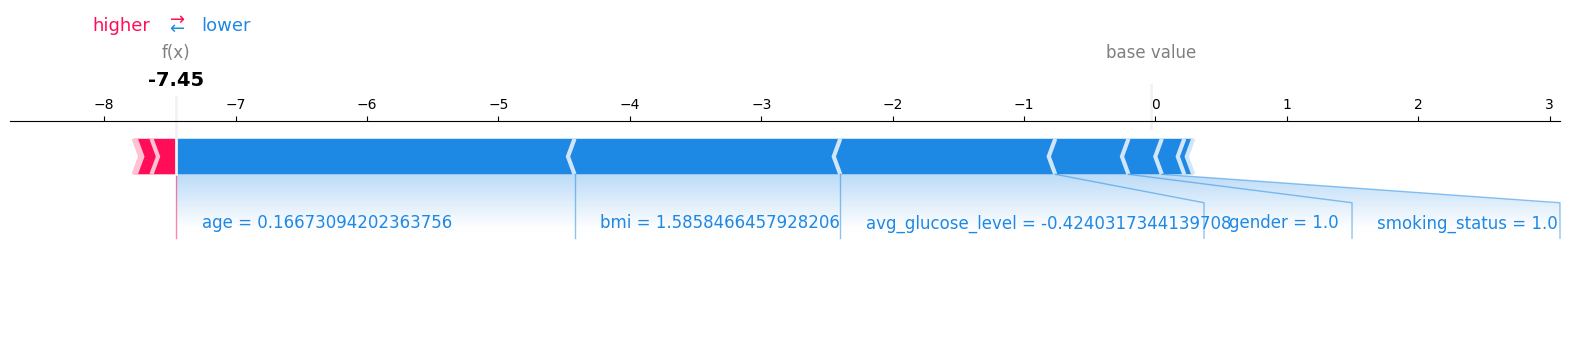

True label       : 1
Predicted label  : 1
Predicted prob.  : 0.8546


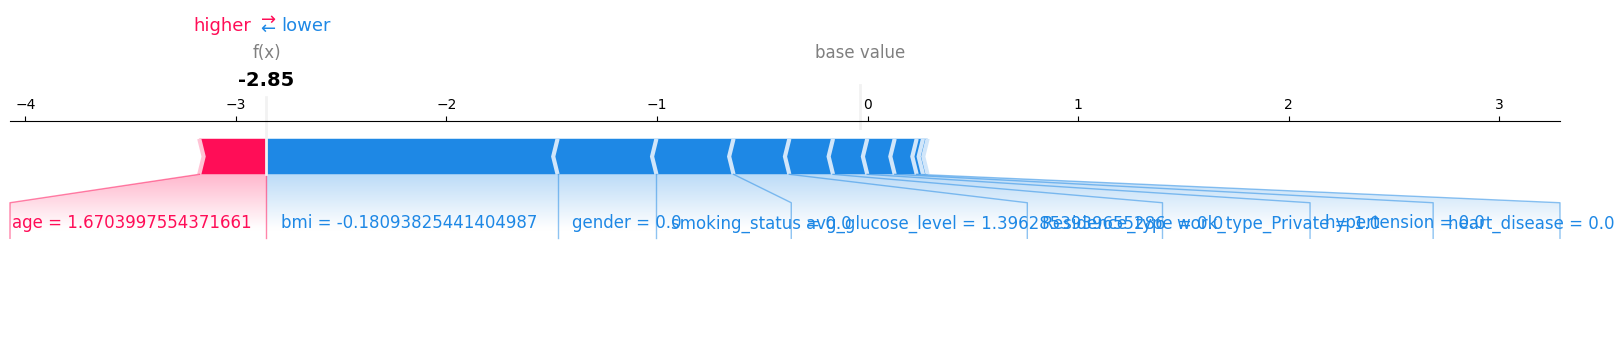

True label       : 1
Predicted label  : 1
Predicted prob.  : 0.5670


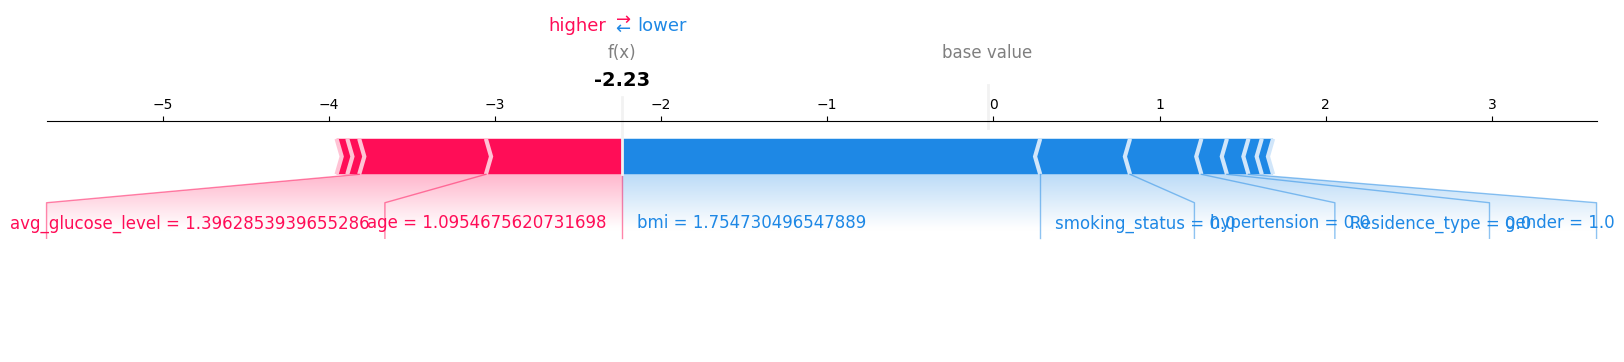

True label       : 0
Predicted label  : 0
Predicted prob.  : 0.3036


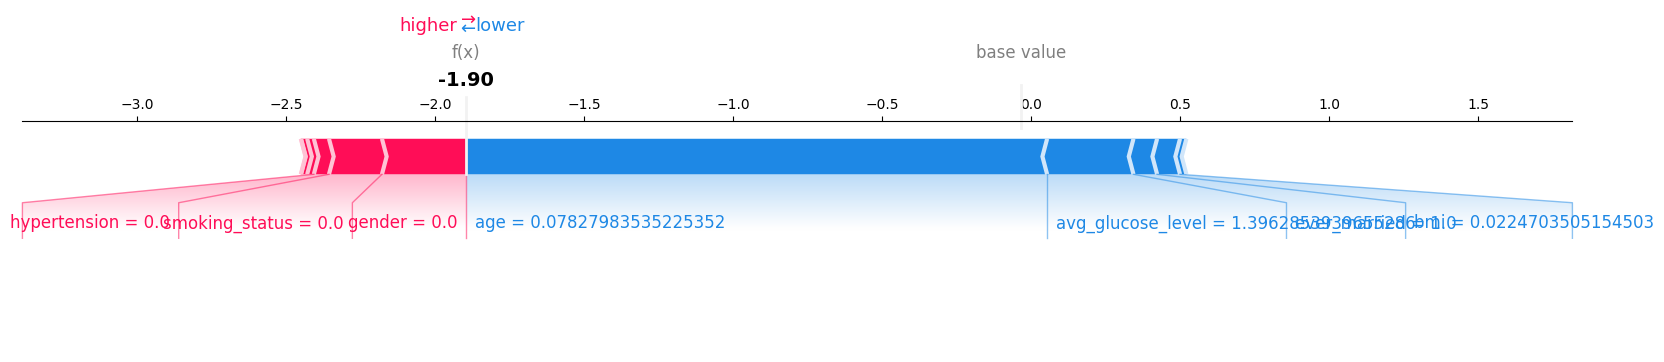

True label       : 0
Predicted label  : 0
Predicted prob.  : 0.2471


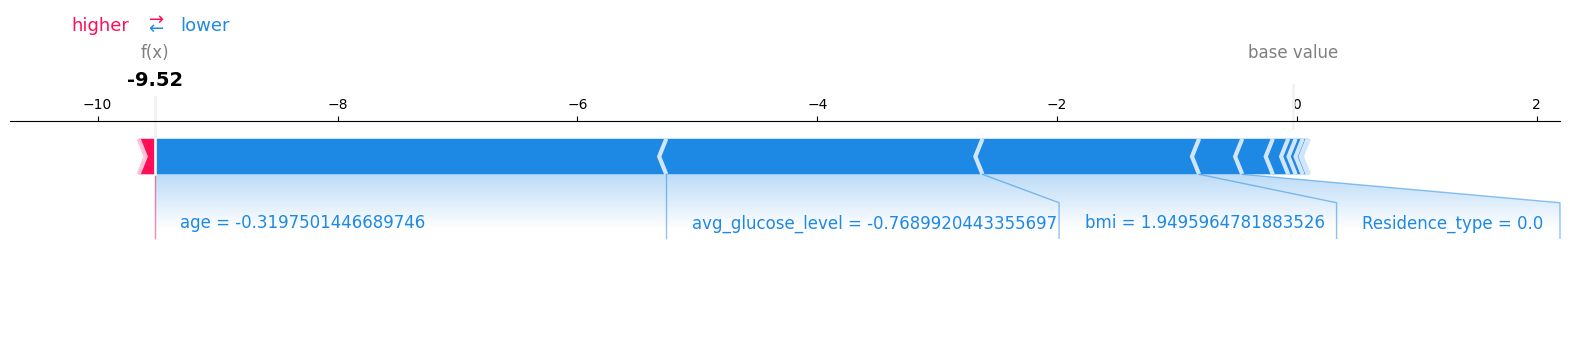

True label       : 0
Predicted label  : 0
Predicted prob.  : 0.3524


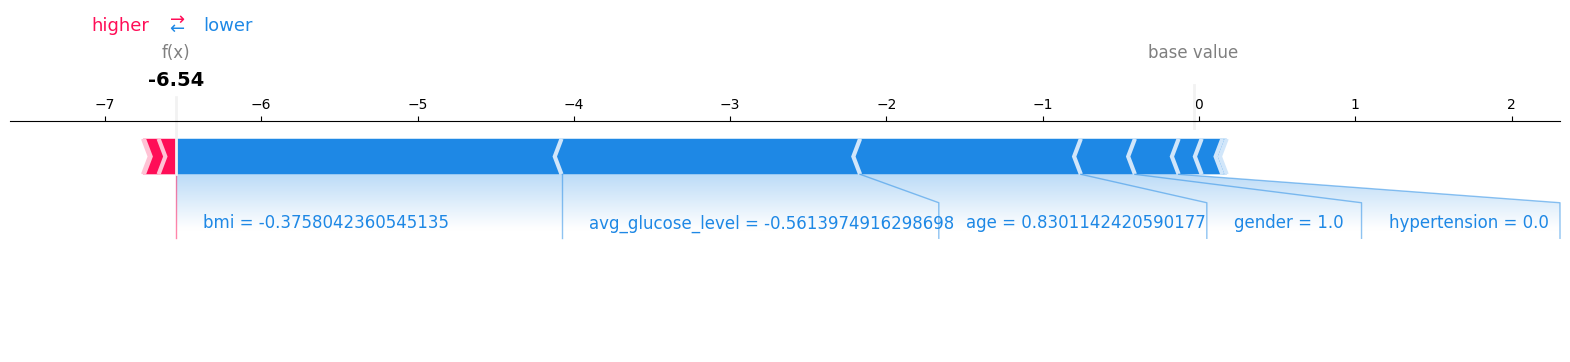

In [26]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Select 5 random stroke and 5 random non-stroke indices
stroke_idx = y_test[y_test == 1].sample(n=3, random_state=42).index
no_stroke_idx = y_test[y_test == 0].sample(n=3, random_state=42).index
selected_idx = list(stroke_idx) + list(no_stroke_idx)

print("Stroke cases:", list(stroke_idx))
print("No-stroke cases:", list(no_stroke_idx))

# Compute SHAP once for all X_test (using XGBoost base learner)
explainer_xgb = shap.TreeExplainer(base_learners[0][1])
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Loop through selected cases
for idx in selected_idx:
    x_instance = X_test.loc[[idx]]   # keep as DataFrame for prediction
    y_true = y_test.loc[idx]

    # Make prediction using full stacking ensemble
    y_pred = stacking_model.predict(x_instance)[0]
    y_prob = stacking_model.predict_proba(x_instance)[:, 1][0]

    # print(f"\n=== Case index: {idx} ===")
    print(f"True label       : {y_true}")
    print(f"Predicted label  : {y_pred}")
    print(f"Predicted prob.  : {y_prob:.4f}")

    # SHAP local explanation (from base learner XGBoost)
    shap.force_plot(
        explainer_xgb.expected_value,
        shap_values_xgb[X_test.index.get_loc(idx), :],
        x_instance.iloc[0, :],
        matplotlib=True
    )

    # Save each plot
    plt.savefig(f"local_shap_case_{idx}_true_{y_true}_pred_{y_pred}.png", bbox_inches="tight")
    plt.close()


## 2x2 4 waterfall SHAP examples

### 4 random stoke or non-storkecase waterfall plot with label

Just change here: `case_idx = y_test[y_test == 0].sample(n=4, random_state=42).index` inside it, `y_test==1` for stroke cases. `y_test=0` for non-storke cases.

No-stroke cases: [3699, 3604, 2814, 1505]
✅ Saved as '100_n_stroke_cases_waterfall_grid_info_oneline.pdf'


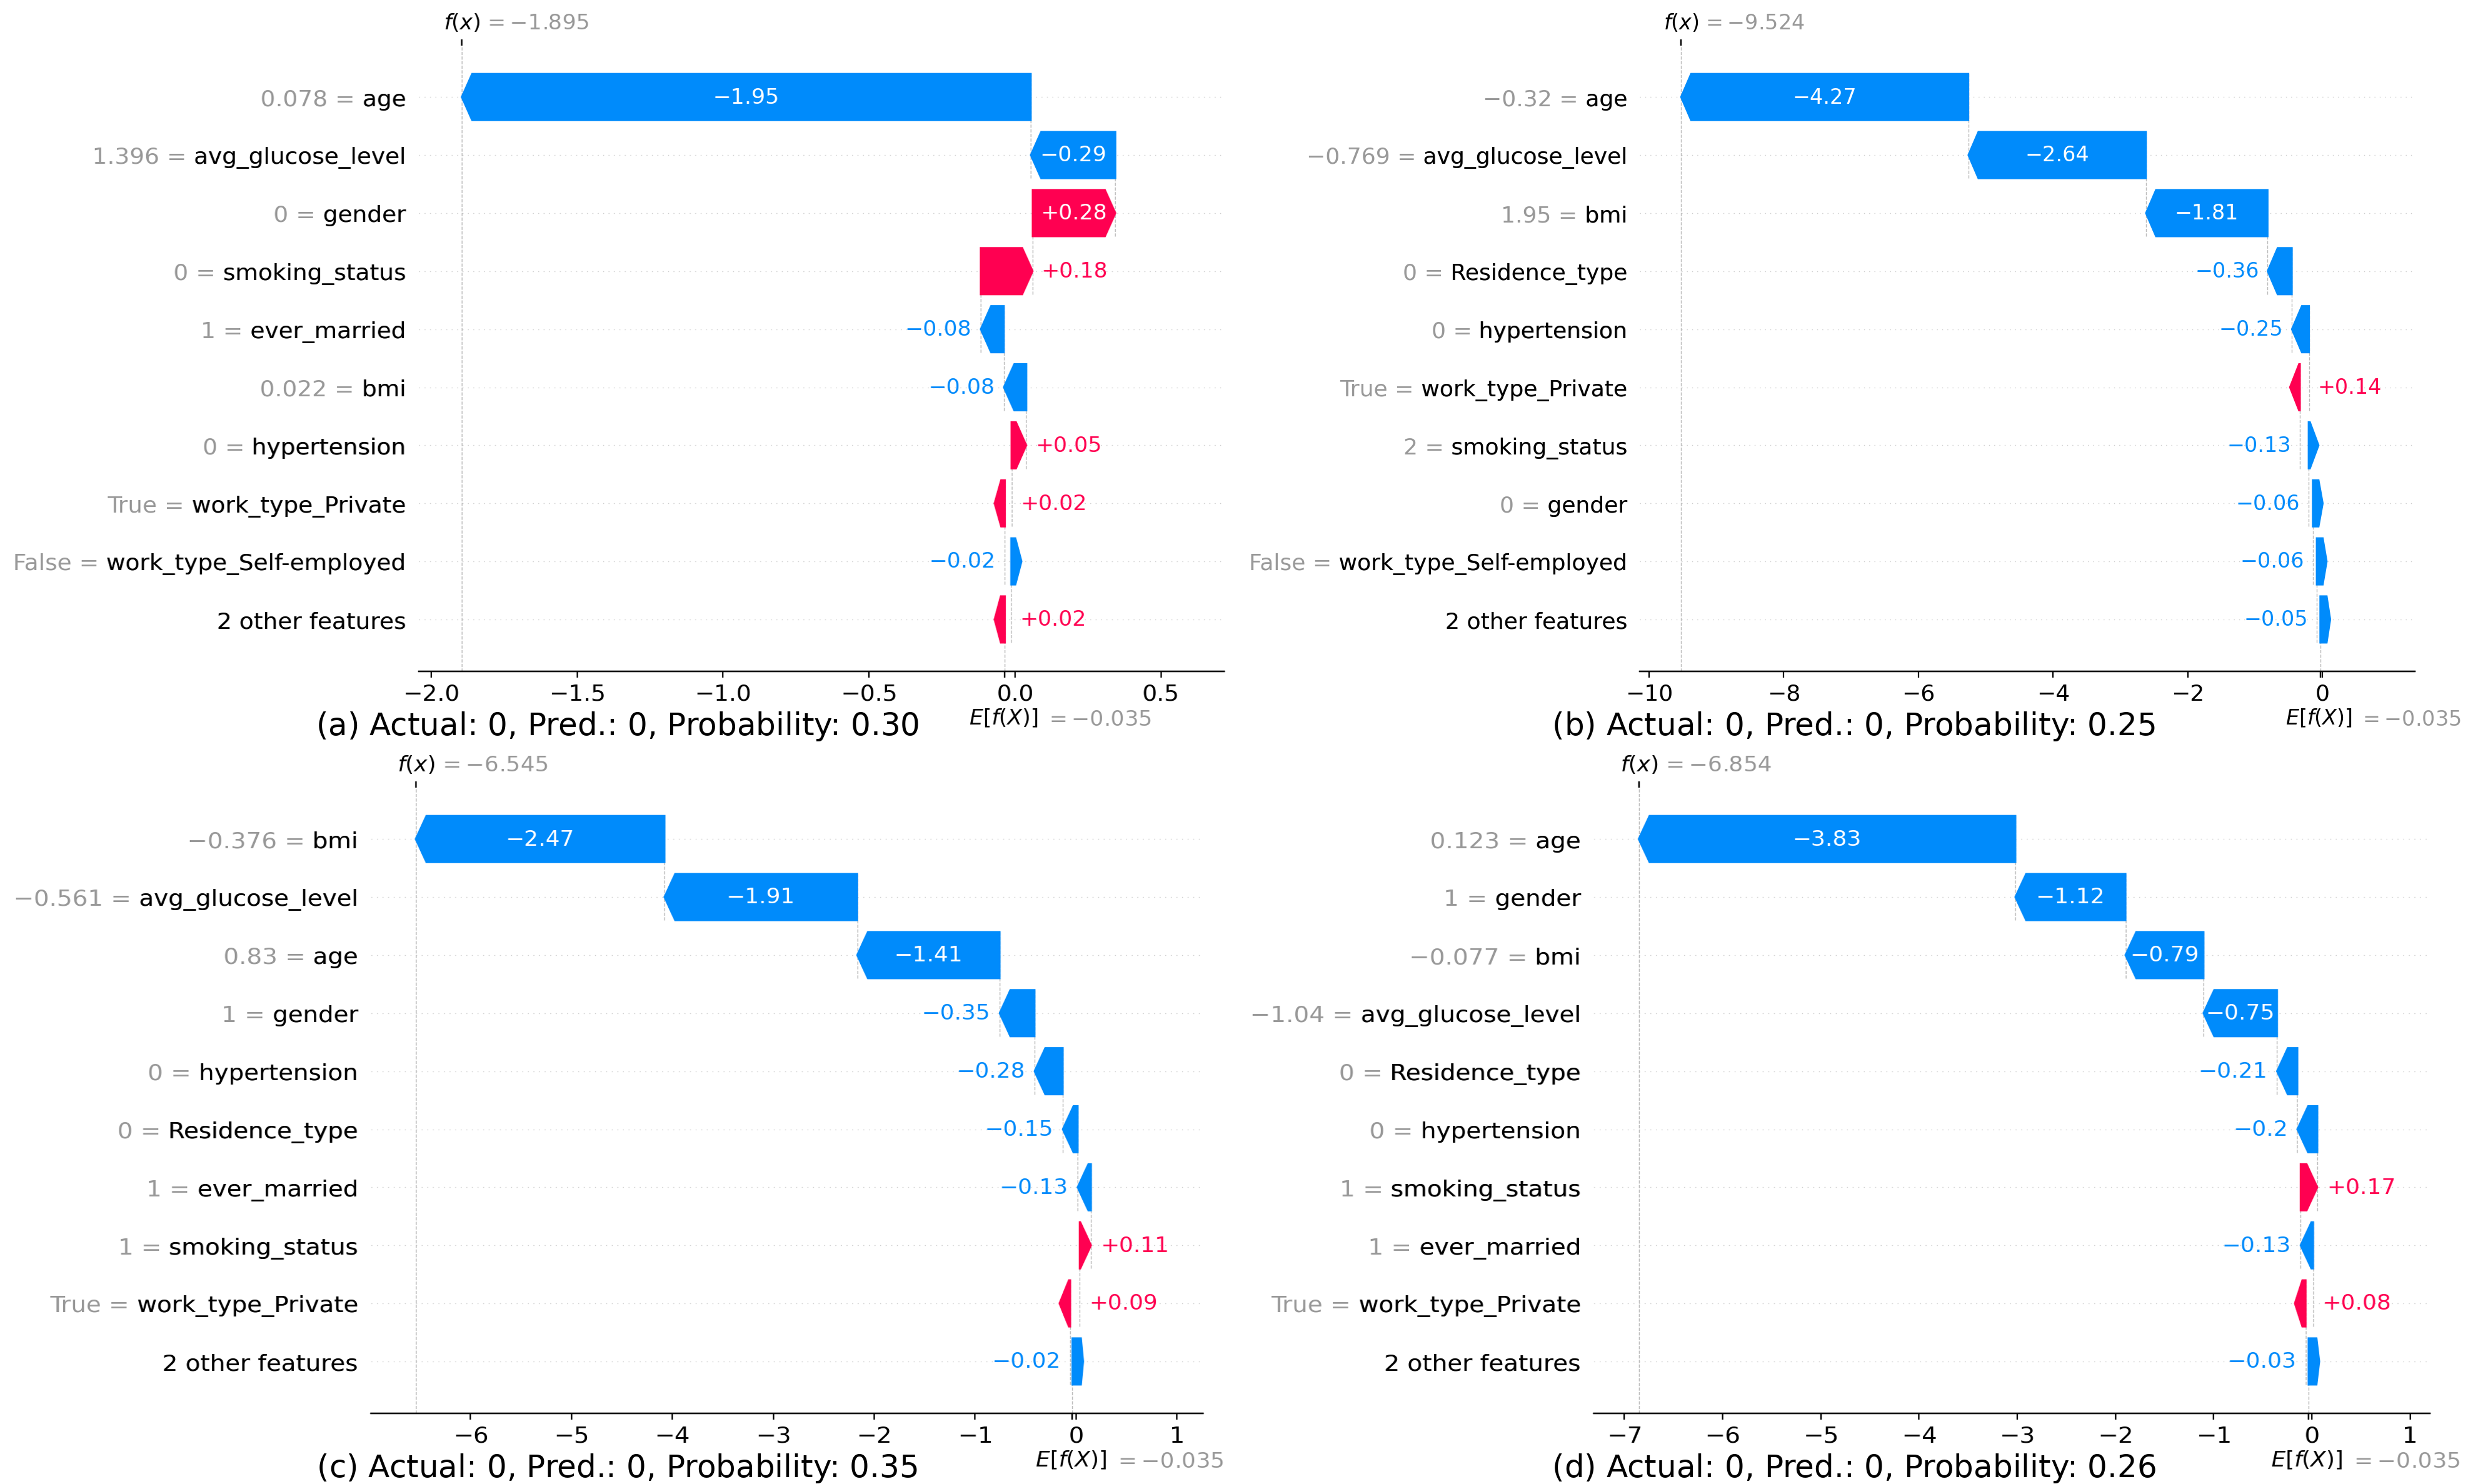

In [31]:
import shap
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import string, matplotlib.font_manager

# --- Select 4 random non-stroke cases ---
case_idx = y_test[y_test == 0].sample(n=4, random_state=42).index
print("No-stroke cases:", list(case_idx))

# --- Compute SHAP values ---
explainer_xgb = shap.TreeExplainer(base_learners[0][1])
shap_values_xgb = explainer_xgb.shap_values(X_test)

# case_idx = case_idx[8:]
# --- Generate individual waterfall plots ---
image_files = []
for i, idx in enumerate(case_idx, start=1):
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values_xgb[X_test.index.get_loc(idx)],
            base_values=explainer_xgb.expected_value,
            data=X_test.loc[idx],
            feature_names=X_test.columns
        ),
        max_display=10,
        show=False
    )
    fname = f"no_stroke_case_{i}.png"
    plt.savefig(fname, bbox_inches="tight", dpi=200)
    plt.close()
    image_files.append(fname)

# --- Combine into a 2×2 grid and annotate ---
images = [Image.open(f) for f in image_files]
w, h = max(im.width for im in images), max(im.height for im in images)
resized = [im.resize((w, h)) for im in images]

cols, rows = 2, 2
grid_w, grid_h = cols * w, rows * h
combined = Image.new("RGB", (grid_w, grid_h), (255, 255, 255))

# --- Font setup ---
font_path = matplotlib.font_manager.findfont("DejaVu Sans")
font = ImageFont.truetype(font_path, 50)  # adjust for text size

draw = ImageDraw.Draw(combined)
labels = list(string.ascii_lowercase)

for i, img in enumerate(resized):
    row, col = divmod(i, cols)
    x, y = col * w, row * h
    combined.paste(img, (x, y))

    # --- Get prediction info ---
    x_instance = X_test.loc[[case_idx[i]]]
    y_true = y_test.loc[case_idx[i]]
    y_pred = stacking_model.predict(x_instance)[0]
    y_prob = stacking_model.predict_proba(x_instance)[:, 1][0]

    # One-line text: (a) True: 1, Pred.: 1, Probability: 0.89
    label_text = f"({labels[i]}) Actual: {y_true}, Pred.: {y_pred}, Probability: {y_prob:.2f}"

    # --- Text size and position ---
    try:
        bbox = draw.textbbox((0, 0), label_text, font=font)
        tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    except AttributeError:
        tw, th = draw.textsize(label_text, font=font)

    x_pos = x + (w - tw) / 2
    y_pos = y + h - th - 10

    # --- Draw bold text with outline ---
    draw.text((x_pos, y_pos), label_text, fill=(0, 0, 0), font=font,
              stroke_width=3, stroke_fill=(255, 255, 255))

# --- Save and show ---
combined.save("100_n_stroke_cases_waterfall_grid_info_oneline.pdf", "PDF", resolution=300.0)
combined.save("100_n_stroke_cases_waterfall_grid_info_oneline.png", dpi=(200, 200))
print("✅ Saved as '100_n_stroke_cases_waterfall_grid_info_oneline.pdf'")

display(IPyImage(filename="100_n_stroke_cases_waterfall_grid_info_oneline.png"))
